# Conditional Generative Model for Images

**based on lab from MIT course ["Introduction to Flow Matching and Diffusion Models 2026"](https://diffusion.csail.mit.edu/2026/index.html)**

In [1]:
from models import VAE, DiffusionTransformerFlowModel
from flow import GaussianConditionalProbabilityPath, LinearAlpha, LinearBeta
from utils.latents import visualize_latent_interpolation
from utils.fid import fid_guidance_sweep
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd

# Part 1. Loading datasets

In [2]:
device = torch.device("cuda:1")

cifar = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            # Converts PIL Image to [0, 1] torch.Tensor
            transforms.ToTensor(),
            transforms.Normalize(  # Scales pixel values to [-1, 1]
                mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
            ),
        ]
    ),
)

cifar_test = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            # Converts PIL Image to [0, 1] torch.Tensor
            transforms.ToTensor(),
            transforms.Normalize(  # Scales pixel values to [-1, 1]
                mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
            ),
        ]
    ),
)


def cifar_reverse_transform(x):
    x = (x + 1.0) / 2.0
    return torch.clamp(x, 0.0, 1.0)

# Part 2: Training process

## 2.1: Training a VAE

In [3]:
vae = VAE(
    data_channels=3,
    hidden_channels=[8, 16, 16],
    beta=0.01,
    reverse_transform=cifar_reverse_transform,
).to(device)

In [4]:
# train_dataloader = DataLoader(dataset=cifar, batch_size=64, shuffle=True)

# trainer = VAETrainer(
#     dataloader=train_dataloader,
# )

# trainer.train(
#     model=vae,
#     num_epochs=100,
#     lr=1e-3,
#     warmup_steps=4 * len(train_dataloader),
#     ckpt_every=1,
#     run_name="vae_jul",
# )

In [5]:
vae = VAE.from_ckpt(ckpt_name=f"epoch_{200}", ckpt_dir="runs/vae_jul2").to(device)

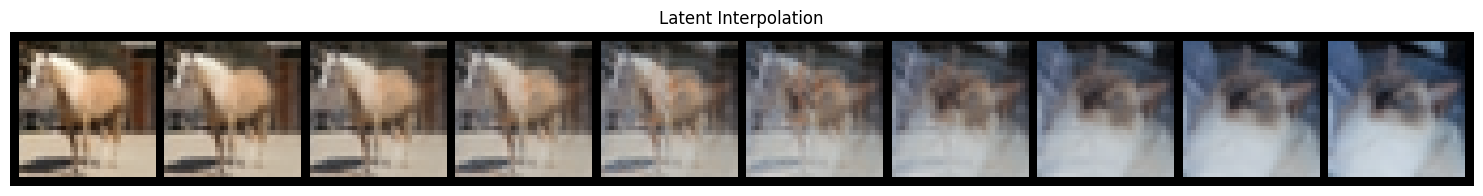

In [6]:
# Perform interpolation in the latent space
samples, _ = next(iter(DataLoader(cifar_test, batch_size=2, shuffle=True)))
samples = samples.to(device)

interpolated_samples = visualize_latent_interpolation(
    x1=samples[:1],
    x2=samples[1:2],
    vae=vae,
    n_steps=10,
)  # n_steps 3 h w

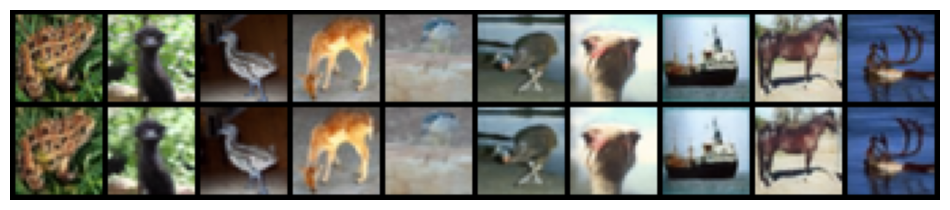

In [7]:
test_dataloader = DataLoader(dataset=cifar_test, batch_size=64, shuffle=True)
test_images, _ = next(iter(test_dataloader))
test_images = test_images[:10]
vae.visualize_samples(images=test_images);

## 2.2 Training a Latent Diffusion Model

In [8]:
latent_cifar = vae.init_latent_dataset(DataLoader(dataset=cifar, batch_size=256))

Converting dataset to latents: 100%|██████████| 196/196 [00:15<00:00, 12.48it/s]


In [9]:
# # Initialize latent probability path
# c = 16
# img_size = 8

# path = GaussianConditionalProbabilityPath(
#     shape=[c, img_size, img_size],
#     alpha=LinearAlpha(),
#     beta=LinearBeta(),
# )

# # Initialize model
# dit = DiffusionTransformerFlowModel(
#     vae=vae,
#     img_size=img_size,
#     patch_size=1,
#     num_layers=14,
#     c=c,
#     dim=512,
#     heads=8,
#     final_dim=64,
#     n_classes=11,
#     null_label=10,
# ).to(device)

In [10]:
# # Initialize trainer
# trainer = LatentCFGTrainer(
#     dataloader=DataLoader(dataset=latent_cifar, batch_size=128, shuffle=True),
#     path=path,
#     latent_stats=vae.get_stats(),
#     null_ratio=0.1,
# )

# trainer.train(
#     model=dit,
#     num_epochs=1000,
#     lr=1e-4,
#     ckpt_every=100,
#     run_name="dit_jul",
#     warmup_steps=10000,
#     ema_decay=0.9999,
# )

In [11]:
dit = DiffusionTransformerFlowModel.from_ckpt(ckpt_name=f"epoch_{2000}", ckpt_dir="runs/dit_jul2").to(device)

# Part 3: Evaluation

In [12]:
dit.visualize_samples(
    save_path="results/gen_samples",
    samples_per_class=10,
    guidance_scales=(1.75, 2.0),
    use_tqdm=True,
);

100%|██████████| 249/249 [01:45<00:00,  2.37it/s]


![image](results/gen_samples.png)

In [13]:
scores = fid_guidance_sweep(dit, "samples/dit_jul2_epoch_2000/", num_timesteps=250)

already sampled
compute FID of a folder with cifar10 statistics
Found 1000 images in the folder samples/dit_jul2_epoch_2000/w_1.25


FID w_1.25 : 100%|██████████| 16/16 [00:06<00:00,  2.49it/s]


already sampled
compute FID of a folder with cifar10 statistics
Found 1000 images in the folder samples/dit_jul2_epoch_2000/w_1.5


FID w_1.5 : 100%|██████████| 16/16 [00:06<00:00,  2.63it/s]


already sampled
compute FID of a folder with cifar10 statistics
Found 1000 images in the folder samples/dit_jul2_epoch_2000/w_1.75


FID w_1.75 : 100%|██████████| 16/16 [00:06<00:00,  2.58it/s]


already sampled
compute FID of a folder with cifar10 statistics
Found 1000 images in the folder samples/dit_jul2_epoch_2000/w_2


FID w_2 : 100%|██████████| 16/16 [00:06<00:00,  2.60it/s]


already sampled
compute FID of a folder with cifar10 statistics
Found 1000 images in the folder samples/dit_jul2_epoch_2000/w_2.25


FID w_2.25 : 100%|██████████| 16/16 [00:06<00:00,  2.60it/s]


In [14]:
df_scores = pd.DataFrame(scores, index=["FID"]).map(lambda x: f"{x:.3f}")
df_scores

,1.25,1.50,1.75,2.00,2.25
FID,81.564,81.642,79.923,78.895,82.643


# ~~~

In [15]:
# vae = VAE(
#     data_channels=3,
#     hidden_channels=[8, 16, 16],
#     beta=0.01,
#     reverse_transform=cifar_reverse_transform,
# ).to(device)

In [16]:
# vae = VAE.from_ckpt(ckpt_name="epoch_200", ckpt_dir="runs/vae_jul2/")

In [17]:
# test_dataloader = DataLoader(dataset=cifar_test, batch_size=64, shuffle=True)
# test_images, _ = next(iter(test_dataloader))
# test_images = test_images[:10]
# vae.visualize_samples(images=test_images);

In [18]:
# img_size = 8
# c = 16

# model = DiffusionTransformerFlowModel(
#     vae=vae,
#     img_size=img_size,
#     patch_size=1,
#     num_layers=16,
#     c=c,
#     dim=768,
#     heads=8,
#     final_dim=64,
#     n_classes=11,
#     null_label=10,
# ).to(device)

# ckpt_path = "runs/dit_jul2/epoch_2000_state.pt"
# ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
# ckpt.keys()

In [19]:
# model = VAE(
#     img_size=32,
#     data_channels=3,
#     hidden_channels=[8, 16, 16],
#     beta=0.01,
#     reverse_transform=cifar_reverse_transform,
# ).to(device)

# ckpt_path = "runs/vae_jul2/epoch_200_state.pt"
# ckpt = torch.load(ckpt_path, map_location="cpu")
# ckpt.keys()

In [20]:
# ckpt = {
#     'model': ckpt['ema'],
#     'raw': ckpt['raw'],
#     'arch': model.get_arch(),
#     'opt': ckpt['opt'],
#     'global_step': ckpt['global_step'],
#     'steps': ckpt['steps'],
#     'losses': ckpt['losses'],
# }

In [21]:
# missing, unexpected = model.load_state_dict(ckpt["model"], strict=False)
# print("missing:", missing)
# print("unexpected:", unexpected)

In [22]:
# ckpt["model"] = model.state_dict()

In [23]:
# model.init_latent_dataset(DataLoader(dataset=cifar, batch_size=512))

In [24]:
# model.vae.init_latent_dataset(DataLoader(dataset=cifar, batch_size=256))

In [25]:
# torch.save(ckpt, ckpt_path)